In [1]:
# Run this once to clear the cache
import shutil, os

cache = '/content/drive/MyDrive/dataset/oasis13d/src/__pycache__'
if os.path.exists(cache):
    shutil.rmtree(cache)
    print("✅ cache cleared")

# Then restart the Colab runtime:
# Runtime menu → Restart Runtime (Ctrl+M .)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.insert(0, '/content/drive/MyDrive/dataset/oasis13d')

Mounted at /content/drive


In [3]:
# Double check Python actually sees the path
import sys
print([p for p in sys.path if 'oasis' in p])
# Must print: ['/content/drive/MyDrive/dataset/oasis13d']

['/content/drive/MyDrive/dataset/oasis13d']


In [5]:
from src.dataset import build_subject_list, OASISDataset
print("✅")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅


In [6]:
from src.preprocessing import (
    ClinicalPreprocessor, compute_class_weights,
    N_FEATURES, N_CLASSES, FEATURE_COLS, CDR_TO_CLASS
)
print("✅ preprocessing imported")

✅ preprocessing imported


In [5]:
from src.encoder_clinical import ClinicalMLPEncoder
import torch

encoder = ClinicalMLPEncoder()
dummy = torch.randn(4, 7)
out = encoder(dummy)
print(f"✅ encoder_clinical works — output: {tuple(out.shape)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ encoder_clinical works — output: (4, 1, 256)


In [6]:
from src.encoder_mri import BrainMRI3DEncoder
import torch

encoder = BrainMRI3DEncoder()
dummy = torch.randn(2, 1, 96, 96, 96)
patches, global_vec = encoder(dummy)
print(f"✅ encoder_mri works — patches: {tuple(patches.shape)}, global: {tuple(global_vec.shape)}")

✅ encoder_mri works — patches: (2, 216, 256), global: (2, 256)


In [4]:
import os

mri_root = '/content/drive/MyDrive/dataset/oasis13d/data'

for root, dirs, files in os.walk(mri_root):
    # Only show first 3 subjects to avoid flooding output
    nii_files = [f for f in files if f.endswith('.nii') or f.endswith('.nii.gz')]
    if nii_files:
        print(root)
        for f in nii_files[:2]:
            print(f'    {f}')
        break  # remove this break to see all

# Also print top-level folders
print('\nTop-level folders:')
for item in sorted(os.listdir(mri_root))[:10]:
    print(f'  {item}')

/content/drive/MyDrive/dataset/oasis13d/data/oasis/OASIS
    OAS1_0001_MR1_mpr_n4_anon_sbj_111_normalised.nii
    OAS1_0003_MR1_mpr_n4_anon_sbj_111_normalised.nii

Top-level folders:
  oasis
  oasis_cross-sectional.csv
  oasis_cross-sectional_facts.pdf


In [7]:
!pip install nibabel -q

from src.dataset import build_subject_list, OASISDataset
from src.preprocessing import ClinicalPreprocessor, CDR_TO_CLASS
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

BASE    = '/content/drive/MyDrive/dataset/oasis13d/data'
CSV     = f'{BASE}/oasis_cross-sectional.csv'
NII_DIR = f'{BASE}/oasis/OASIS'

df     = build_subject_list(CSV, NII_DIR)
labels = df['CDR'].map(CDR_TO_CLASS).values
df_tr, df_va = train_test_split(df, test_size=0.2, random_state=42, stratify=labels)

prep = ClinicalPreprocessor()
prep.fit_transform(df_tr)

train_ds = OASISDataset(df_tr, prep, augment=True)
loader   = DataLoader(train_ds, batch_size=2, shuffle=True)

mri, clinical, label = next(iter(loader))
print(f"MRI      : {tuple(mri.shape)}")
print(f"Clinical : {tuple(clinical.shape)}")
print(f"Label    : {label.tolist()}")

NIfTI scanner   : found 416 subjects in /content/drive/MyDrive/dataset/oasis13d/data/oasis/OASIS
Subject list    : 416 subjects with both CSV and NIfTI
Feature matrix : (332, 7)  (N_samples × 7 features)
Features       : ['Age', 'M/F', 'Educ', 'SES', 'MMSE', 'eTIV', 'nWBV']
Value range    : [-4.84, 3.22]  (after StandardScaler)
Class distribution:
  class 0 (Non-demented): ████████████████████████████████████████████████████████████ 252
  class 1 (Very mild): ████████████████████████████████████████████████████████ 56
  class 2 (Mild/Moderate): ████████████████████████ 24
OASISDataset    : 332 subjects  | augment=True  | shape=(96, 96, 96)
MRI      : (2, 1, 96, 96, 96)
Clinical : (2, 7)
Label    : [1, 1]


In [8]:
from src.fusion import CrossModalFusion, attention_to_volume
import torch

D, B = 256, 4
patches    = torch.randn(B, 216, D)
global_vec = torch.randn(B, D)
clin_token = torch.randn(B, 1, D)

fusion = CrossModalFusion()
fused, attn_w = fusion(patches, global_vec, clin_token)

print(f"fused    : {tuple(fused.shape)}")     # (4, 256)
print(f"attn_w   : {tuple(attn_w.shape)}")    # (4, 8, 1, 216)
print("✅ fusion works")

fused    : (4, 256)
attn_w   : (4, 4, 1, 216)
✅ fusion works


In [5]:
import os
import shutil

LOCAL_CACHE = '/content/mri_cache'
NII_DIR     = '/content/drive/MyDrive/dataset/oasis13d/data/oasis/OASIS'

os.makedirs(LOCAL_CACHE, exist_ok=True)

files = [f for f in os.listdir(NII_DIR) if f.endswith('.nii')]
print(f"Copying {len(files)} files to local cache...")

for i, f in enumerate(files):
    src = os.path.join(NII_DIR, f)
    dst = os.path.join(LOCAL_CACHE, f)
    
    if not os.path.exists(dst):
        shutil.copy2(src, dst)
    
    if (i+1) % 50 == 0:
        print(f"{i+1}/{len(files)} copied")

print("✅ All files cached locally")

Copying 436 files to local cache...
50/436 copied
100/436 copied
150/436 copied
200/436 copied
250/436 copied
300/436 copied
350/436 copied
400/436 copied
✅ All files cached locally


In [ ]:


import sys
sys.path.insert(0, '/content/drive/MyDrive/dataset/oasis13d')

!pip install nibabel -q

%run /content/drive/MyDrive/dataset/oasis13d/train.py

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device : cpu

── Loading data ──
NIfTI scanner   : found 416 subjects in /content/mri_cache
Subject list    : 416 subjects with both CSV and NIfTI
Train: 332  Val: 84
Feature matrix : (332, 7)  (N_samples × 7 features)
Features       : ['Age', 'M/F', 'Educ', 'SES', 'MMSE', 'eTIV', 'nWBV']
Value range    : [-4.84, 3.22]  (after StandardScaler)
Class distribution:
  class 0 (Non-demented): ████████████████████████████████████████████████████████████ 252
  class 1 (Very mild): ████████████████████████████████████████████████████████ 56
  class 2 (Mild/Moderate): ████████████████████████ 24
OASISDataset    : 3

In [ ]:
!pip install nibabel -q

import sys
sys.path.insert(0, '/content/drive/MyDrive/dataset/oasis13d')

%run /content/drive/MyDrive/dataset/oasis13d/train.py

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device : cuda
GPU    : Tesla T4

── Loading data ──
NIfTI scanner   : found 416 subjects in /content/mri_cache
Subject list    : 416 subjects with both CSV and NIfTI
Train: 332  Val: 84
Feature matrix : (332, 7)  (N_samples × 7 features)
Features       : ['Age', 'M/F', 'Educ', 'SES', 'MMSE', 'eTIV', 'nWBV']
Value range    : [-4.84, 3.22]  (after StandardScaler)
Class distribution:
  class 0 (Non-demented): ████████████████████████████████████████████████████████████ 252
  class 1 (Very mild): ████████████████████████████████████████████████████████ 56
  class 2 (Mild/Moderate): ████████████████████████ 24
OASISDataset    : 332 subjects  | augment=True  | shape=(96, 96, 96)
OASISDataset    : 84 subjects  | augment=False  | shape=(96,

In [8]:
!ls /content/mri_cache | wc -l  # count files
!ls /content/mri_cache | head    # see some examples

436


OAS1_0001_MR1_mpr_n4_anon_sbj_111_normalised.nii
OAS1_0002_MR1_mpr_n4_anon_sbj_111_normalised.nii
OAS1_0003_MR1_mpr_n4_anon_sbj_111_normalised.nii
OAS1_0004_MR1_mpr_n4_anon_sbj_111_normalised.nii
OAS1_0005_MR1_mpr_n4_anon_sbj_111_normalised.nii
OAS1_0006_MR1_mpr_n4_anon_sbj_111_normalised.nii
OAS1_0007_MR1_mpr_n3_anon_sbj_111_normalised.nii
OAS1_0009_MR1_mpr_n4_anon_sbj_111_normalised.nii
OAS1_0010_MR1_mpr_n4_anon_sbj_111_normalised.nii
OAS1_0011_MR1_mpr_n4_anon_sbj_111_normalised.nii


In [7]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

False


AssertionError: Torch not compiled with CUDA enabled

In [17]:
import shutil, os

# Clear pycache
cache = '/content/drive/MyDrive/dataset/oasis13d/src/__pycache__'
if os.path.exists(cache):
    shutil.rmtree(cache)
    print("✅ pycache cleared")

# Also clear top level pycache
cache2 = '/content/drive/MyDrive/dataset/oasis13d/__pycache__'
if os.path.exists(cache2):
    shutil.rmtree(cache2)
    print("✅ top pycache cleared")

In [2]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/dataset/oasis13d')

from src.preprocessing import ClinicalPreprocessor

print("✅ import works")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ import works


In [13]:
import os

init_path = '/content/drive/MyDrive/dataset/oasis13d/src/__init__.py'

print("init exists:", os.path.exists(init_path))
print("files in src:", os.listdir('/content/drive/MyDrive/dataset/oasis13d/src'))

init exists: True
files in src: ['encoder_clinical.py', 'preprocessing.py', 'encoder_mri.py', '__init__.py', 'dataset.py', 'fusion.py', 'model.py', '__pycache__', 'evaluate.py']


In [1]:
import sys
sys.path.append('/content/drive/MyDrive/dataset/oasis13d/src')

from preprocessing import ClinicalPreprocessor

print("✅ works (direct import)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ works (direct import)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cpu

── Loading validation data ──
NIfTI scanner   : found 416 subjects in /content/mri_cache
Subject list    : 416 subjects with both CSV and NIfTI
Feature matrix : (332, 7)  (N_samples × 7 features)
Features       : ['Age', 'M/F', 'Educ', 'SES', 'MMSE', 'eTIV', 'nWBV']
Value range    : [-4.84, 3.22]  (after StandardScaler)
Class distribution:
  class 0 (Non-demented): ████████████████████████████████████████████████████████████ 252
  class 1 (Very mild): ████████████████████████████████████████████████████████ 56
  class 2 (Mild/Moderate): ████████████████████████ 24
OASISDataset    : 84 subjects

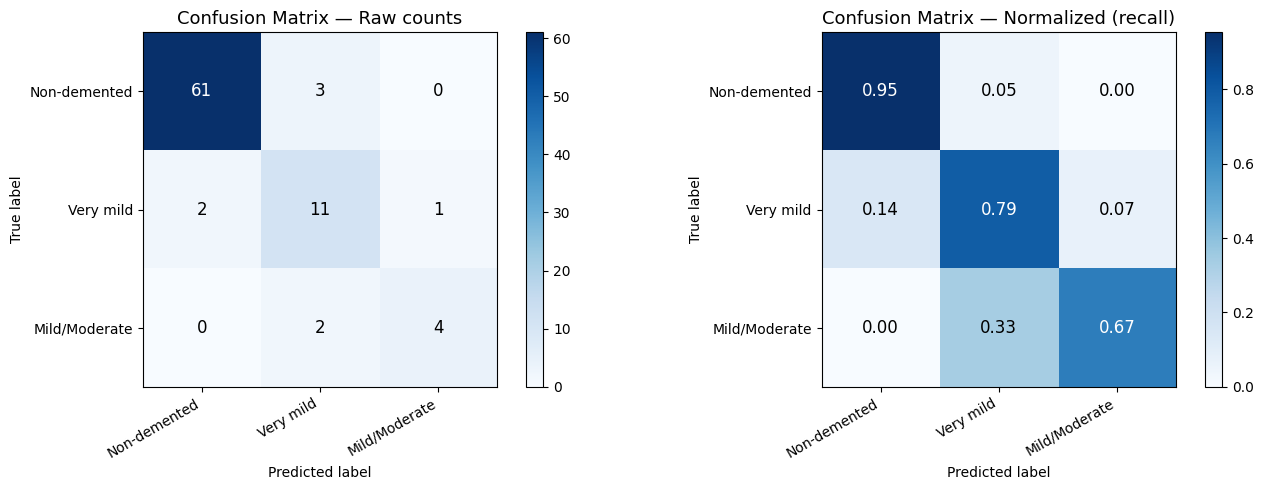

Confusion matrix saved → /content/drive/MyDrive/dataset/oasis13d/results/confusion_matrix.png

── Part 2: Feature importance ──

  CLINICAL FEATURE IMPORTANCE
  (gate weights from FeatureWiseAttention)
  MMSE     █████████████████              0.575
  SES      ██████████████                 0.484
  eTIV     ██████████████                 0.482
  Educ     ██████████████                 0.473
  M/F      ██████████████                 0.469
  Age      █████████████                  0.460
  nWBV     █████████████                  0.453


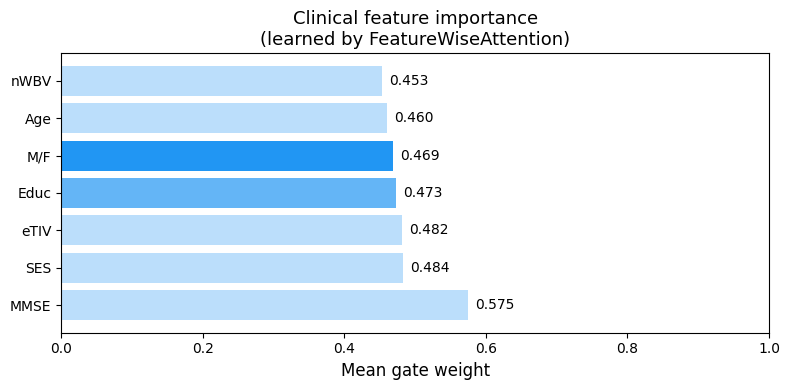

Feature importance saved → /content/drive/MyDrive/dataset/oasis13d/results/feature_importance.png

── Part 3: Attention maps ──


/content/drive/MyDrive/dataset/oasis13d/src/evaluate.py:360: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/drive/MyDrive/dataset/oasis13d/src/evaluate.py:366: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


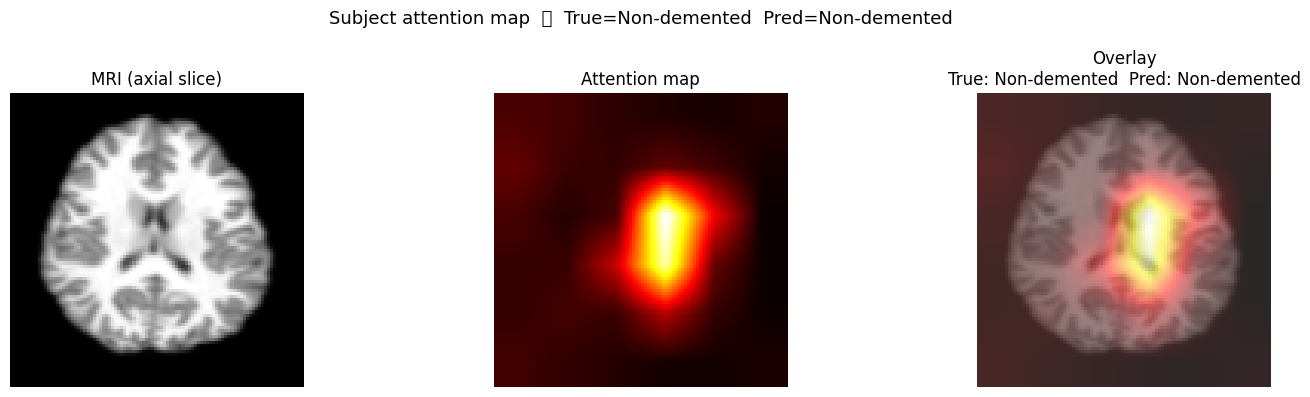

Attention map saved → /content/drive/MyDrive/dataset/oasis13d/results/attn_class0_subj1.png


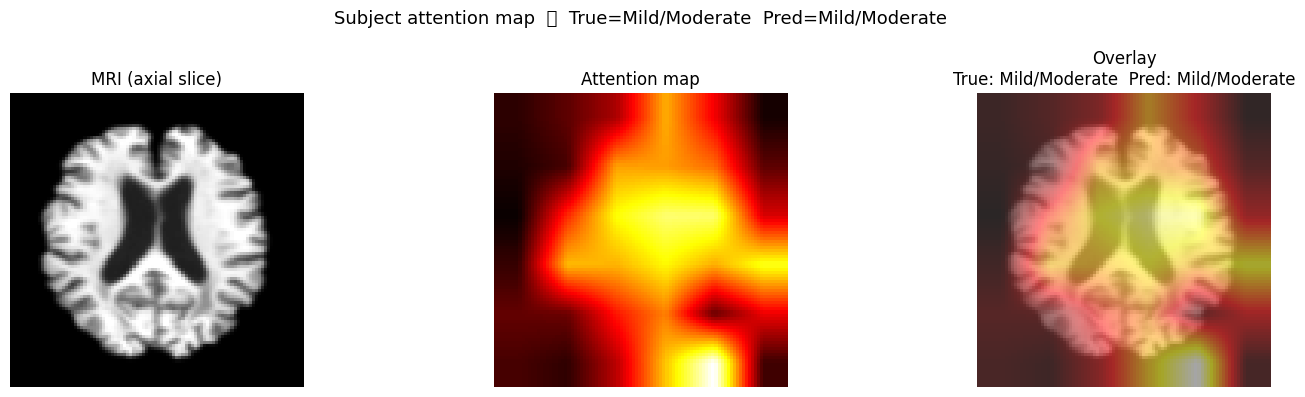

Attention map saved → /content/drive/MyDrive/dataset/oasis13d/results/attn_class2_subj1.png


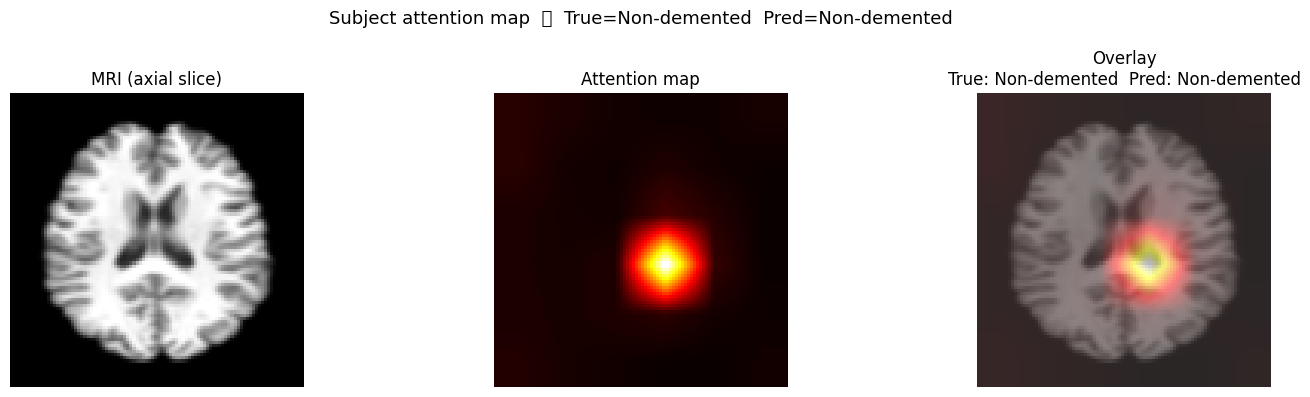

Attention map saved → /content/drive/MyDrive/dataset/oasis13d/results/attn_class0_subj2.png


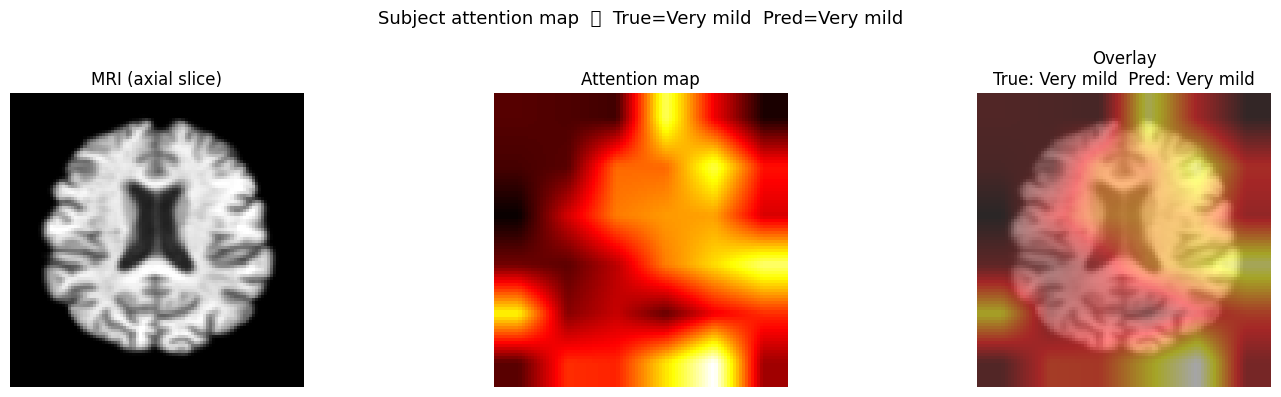

Attention map saved → /content/drive/MyDrive/dataset/oasis13d/results/attn_class1_subj1.png


/content/drive/MyDrive/dataset/oasis13d/src/evaluate.py:360: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/drive/MyDrive/dataset/oasis13d/src/evaluate.py:366: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


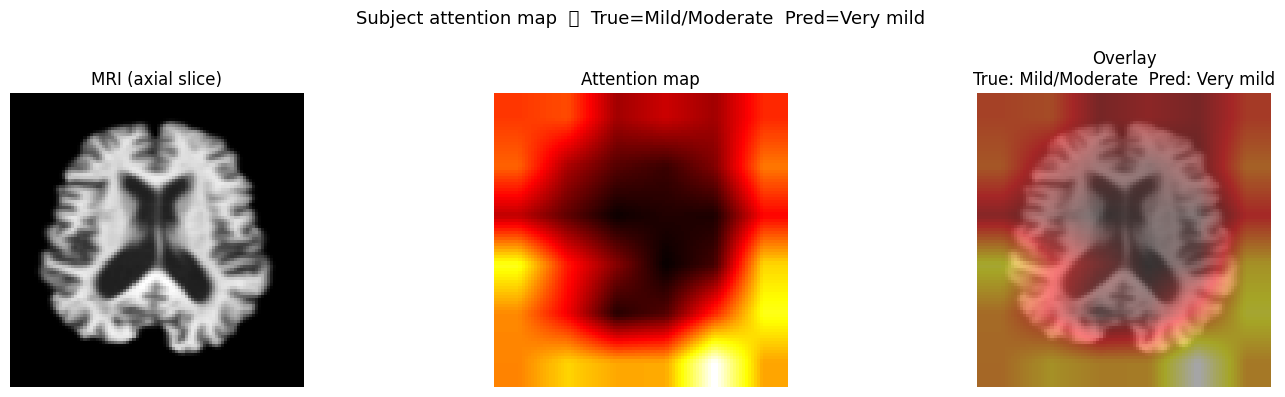

Attention map saved → /content/drive/MyDrive/dataset/oasis13d/results/attn_class2_subj2.png


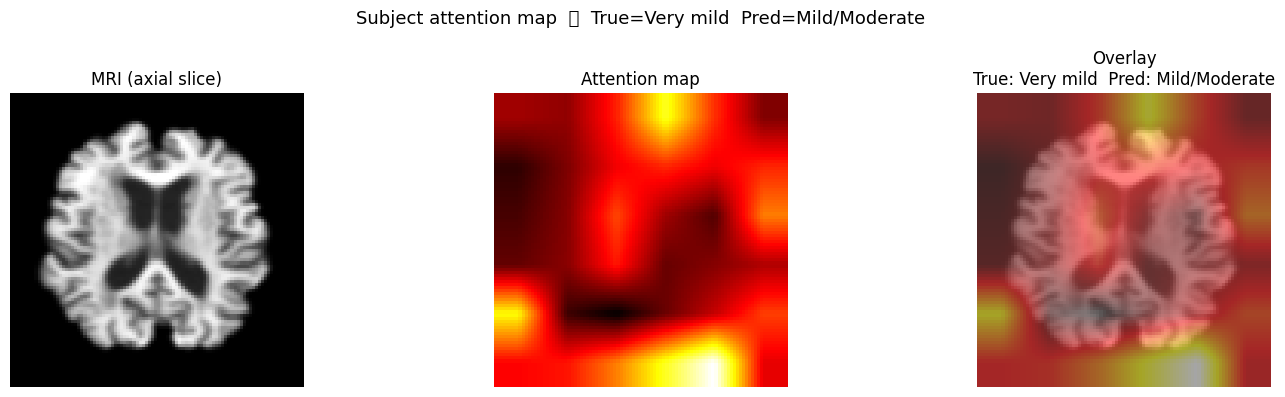

Attention map saved → /content/drive/MyDrive/dataset/oasis13d/results/attn_class1_subj2.png

── Part 4: Ablation study ──

  ABLATION STUDY
  Mode                 Accuracy   F1 (weighted)      Kappa
  -------------------------------------------------------
Loaded: /content/drive/MyDrive/dataset/oasis13d/checkpoints/best_stage1.pt  (epoch=8  val_acc=0.9048)
  clinical_only          0.5119          0.5511     0.0641
Loaded: /content/drive/MyDrive/dataset/oasis13d/checkpoints/best_stage1.pt  (epoch=8  val_acc=0.9048)
  mri_only               0.7619          0.6589     0.0000
Loaded: /content/drive/MyDrive/dataset/oasis13d/checkpoints/best_stage1.pt  (epoch=8  val_acc=0.9048)
  concat_only            0.7500          0.6531    -0.0197
Loaded: /content/drive/MyDrive/dataset/oasis13d/checkpoints/best_stage1.pt  (epoch=8  val_acc=0.9048)
  full                   0.9048          0.9061     0.7574 ← proposed



/content/drive/MyDrive/dataset/oasis13d/src/evaluate.py:517: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(modes, rotation=20, ha='right')
/content/drive/MyDrive/dataset/oasis13d/src/evaluate.py:517: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(modes, rotation=20, ha='right')
/content/drive/MyDrive/dataset/oasis13d/src/evaluate.py:517: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(modes, rotation=20, ha='right')


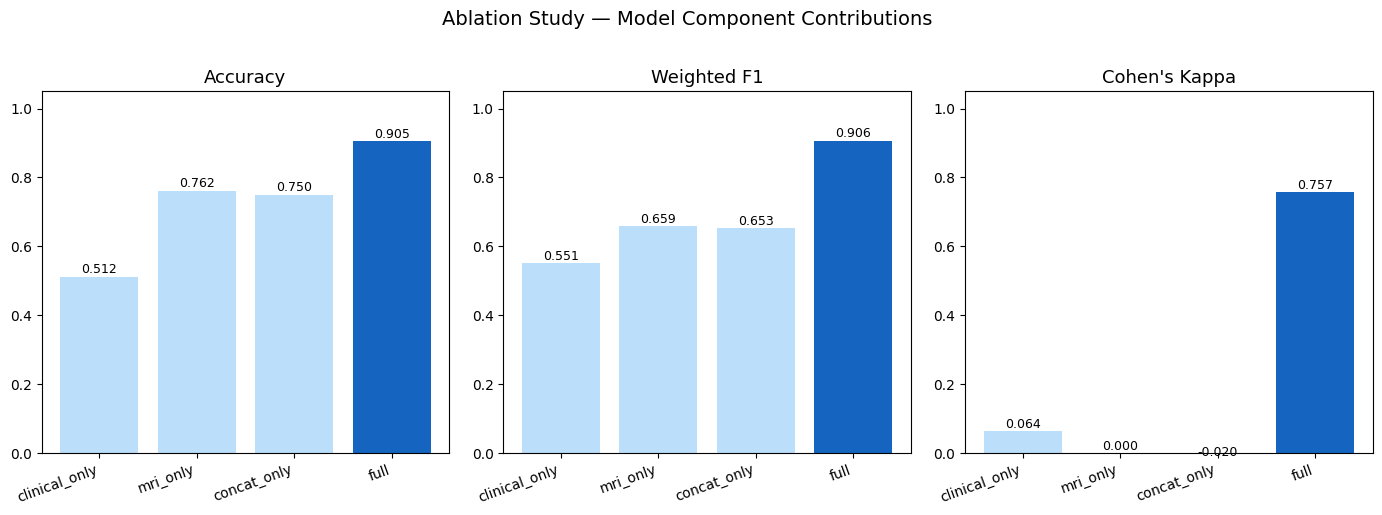

Ablation chart saved → /content/drive/MyDrive/dataset/oasis13d/results/ablation_study.png

✅ Evaluation complete — all figures saved to:
   /content/drive/MyDrive/dataset/oasis13d/results


<Figure size 640x480 with 0 Axes>

In [6]:
!pip install nibabel -q

%run /content/drive/MyDrive/dataset/oasis13d/src/evaluate.py